In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Phase 1: Data Audit (EDA)

In [4]:
df = pd.read_csv('ecommerce_500k.csv')

In [5]:
df.head()

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


Insights :
Identifiers : order_id, customer_id, product_id

Product Features: category, sub_category, product_base_price, discount_percentage, final_price, quantity

Customer Features: loyalty_tier,  is_first_purchase , customer_lifetime_value

Behavioural Features: session_duration_mins, pages_viewed, clicks_to_purchase

Location Feature: city

Return Features: is_returned,   return_reason



In [6]:
df.shape

(500000, 30)

Records : 500000
Columns : 30

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  object 
 4   category                 500000 non-null  object 
 5   sub_category             500000 non-null  object 
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  object 
 13  days_to_deliver          484751 non-null  float64
 14  paym

In [8]:
df.columns.values

array(['order_id', 'customer_id', 'product_id', 'order_date', 'category',
       'sub_category', 'product_base_price', 'discount_percentage',
       'final_price', 'quantity', 'total_amount', 'shipping_cost',
       'shipping_method', 'days_to_deliver', 'payment_method', 'rating',
       'num_reviews', 'customer_age', 'customer_gender', 'country',
       'city', 'loyalty_tier', 'is_first_purchase',
       'customer_lifetime_value', 'session_duration_mins', 'pages_viewed',
       'clicks_to_purchase', 'is_returned', 'return_reason',
       'is_cancelled'], dtype=object)

In [10]:
df.isnull().sum()

order_id                        0
customer_id                     0
product_id                      0
order_date                      0
category                        0
sub_category                    0
product_base_price              0
discount_percentage             0
final_price                     0
quantity                        0
total_amount                    0
shipping_cost               15066
shipping_method                 0
days_to_deliver             15249
payment_method                  0
rating                      14990
num_reviews                     0
customer_age                14928
customer_gender                 0
country                         0
city                            0
loyalty_tier                    0
is_first_purchase               0
customer_lifetime_value     15004
session_duration_mins       14725
pages_viewed                14814
clicks_to_purchase              0
is_returned                     0
return_reason              440096
is_cancelled  

In [12]:
missing_df = pd.DataFrame({
    'Missing_Count':df.isnull().sum(),
    'Missing_Percentage':(df.isnull().sum()/len(df))*100
})
missing_df = missing_df.sort_values(
    by='Missing_Percentage',
    ascending=False
)
print(missing_df)

                         Missing_Count  Missing_Percentage
return_reason                   440096             88.0192
days_to_deliver                  15249              3.0498
shipping_cost                    15066              3.0132
customer_lifetime_value          15004              3.0008
rating                           14990              2.9980
customer_age                     14928              2.9856
pages_viewed                     14814              2.9628
session_duration_mins            14725              2.9450
num_reviews                          0              0.0000
is_returned                          0              0.0000
clicks_to_purchase                   0              0.0000
is_first_purchase                    0              0.0000
loyalty_tier                         0              0.0000
city                                 0              0.0000
country                              0              0.0000
customer_gender                      0              0.00

Insight: 
'return_reason' has 88.0192% null values 
If is_returned = 0 then it is completely valid

In [13]:
df[df['is_returned']==0]['return_reason'].isnull().mean()*100

100.0

In [14]:
df.duplicated().sum()

0

In [15]:
df.dtypes

order_id                     int64
customer_id                  int64
product_id                   int64
order_date                  object
category                    object
sub_category                object
product_base_price         float64
discount_percentage          int64
final_price                float64
quantity                     int64
total_amount               float64
shipping_cost              float64
shipping_method             object
days_to_deliver            float64
payment_method              object
rating                     float64
num_reviews                  int64
customer_age               float64
customer_gender             object
country                     object
city                        object
loyalty_tier                object
is_first_purchase            int64
customer_lifetime_value    float64
session_duration_mins      float64
pages_viewed               float64
clicks_to_purchase           int64
is_returned                  int64
return_reason       

Phase 2: Pricing Data Skewness

In [17]:
price_cols = [
    'product_base_price',
    'discount_percentage',
    'final_price',
    'total_amount',
    'shipping_cost'
]

df[price_cols].skew()


product_base_price     2.008356
discount_percentage    0.768376
final_price            2.107809
total_amount           4.384068
shipping_cost          1.987428
dtype: float64

Skewness

-0.5 to 0.5    --> Approximately Normal

0.5  to 1      --> Moderately Skewed

greater than 1      --> Highly Skewed

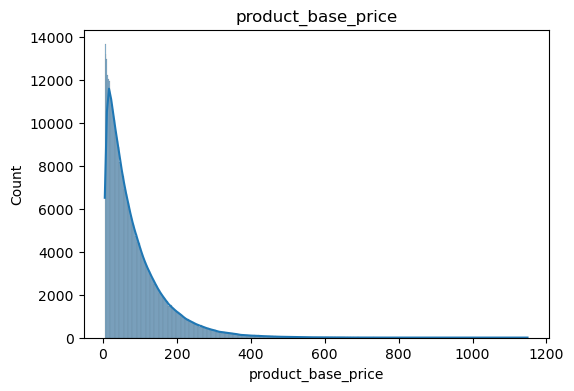

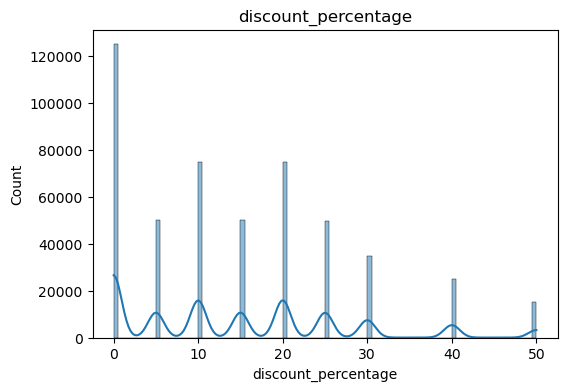

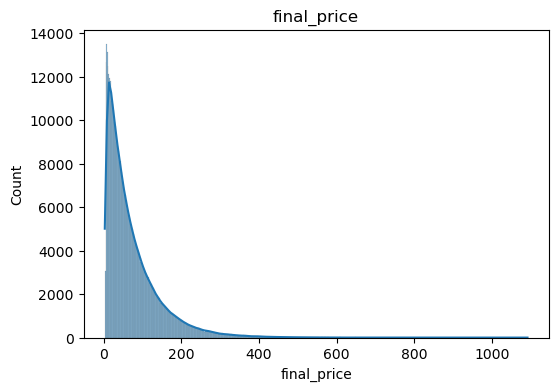

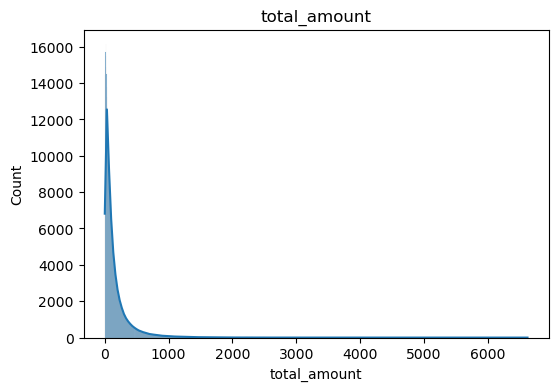

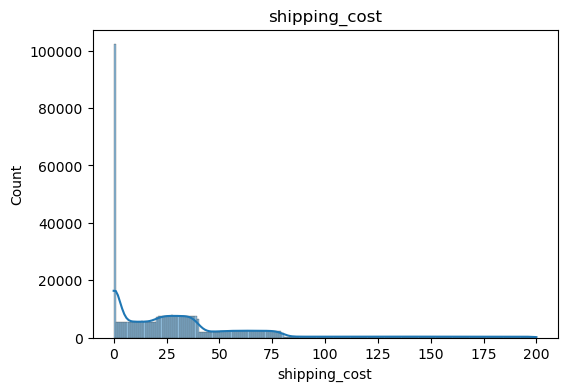

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in price_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.title(col)
    plt.show()

Phase 3: Which Categorical Columns Will Break ML Pipeline?

In [20]:
category_cols = df.select_dtypes(include='object').columns
print(category_cols)

Index(['order_date', 'category', 'sub_category', 'shipping_method',
       'payment_method', 'customer_gender', 'country', 'city', 'loyalty_tier',
       'return_reason'],
      dtype='object')


In [21]:
for col in category_cols:
    print(col,df[col].unique())

order_date ['2022-07-31' '2023-09-25' '2022-03-26' ... '2022-12-05' '2023-05-05'
 '2022-04-12']
category ['Clothing' 'Automotive' 'Books' 'Toys' 'Beauty' 'Sports' 'Electronics'
 'Furniture' 'Home & Kitchen' 'Food & Grocery']
sub_category ['Men' 'Car Care' 'Textbooks' 'Non-Fiction' 'Women' 'Action Figures'
 'Skincare' 'Electronics' 'Fitness' 'TVs' 'Fragrance' 'Board Games'
 'Mobiles' 'Living Room' 'Appliances' 'Bedding' 'Accessories' 'Snacks'
 'Wellness' 'Bedroom' 'Cycling' 'Outdoor' 'Tools' 'Educational' 'Cookware'
 'Footwear' 'Team Sports' 'Beverages' 'Office' 'Comics' 'Cameras'
 'Magazines' 'Dolls' 'Kids' 'Fiction' 'Makeup' 'Decor' 'Frozen' 'Haircare'
 'Storage' 'Dairy' 'Parts' 'Organic' 'Laptops' 'Water Sports']
shipping_method ['Same-Day' 'Standard' 'Express' 'Free']
payment_method ['UPI' 'Credit Card' 'Debit Card' 'Net Banking' 'COD' 'Wallet']
customer_gender ['Female' 'Other' 'Male']
country ['Canada' 'Australia' 'France' 'India' 'USA' 'UAE' 'UK' 'Germany']
city ['Bangalore' 'Tor

Cardinality Check
A categorical column usually breaks or creates problems in an ML pipeline because of:

Very high cardinality (too many unique values),

Unseen categories in test/production data


In [22]:
for col in category_cols:
    print(col,df[col].nunique())

order_date 1095
category 10
sub_category 45
shipping_method 4
payment_method 6
customer_gender 3
country 8
city 15
loyalty_tier 4
return_reason 5


Insights:
order_date is at high risk
sub_category is at moderate
rest columns are safe

Phase 4 :
Why are customers returning products? Find the patterns that matter to the business.

What percentage of orders are returned?

In [23]:
df['is_returned'].value_counts(normalize=True)*100

is_returned
0    88.0192
1    11.9808
Name: proportion, dtype: float64

Category vs Returns

In [24]:
category_returns = pd.crosstab(
    df['category'],
    df['is_returned'],
    normalize='index'
)*100

category_returns

is_returned,0,1
category,,
Automotive,87.952508,12.047492
Beauty,87.942879,12.057121
Books,87.958010,12.041990
Clothing,88.180884,11.819116
Electronics,87.886105,12.113895
Food & Grocery,88.067703,11.932297
Furniture,87.901675,12.098325
Home & Kitchen,88.105278,11.894722
Sports,88.135729,11.864271


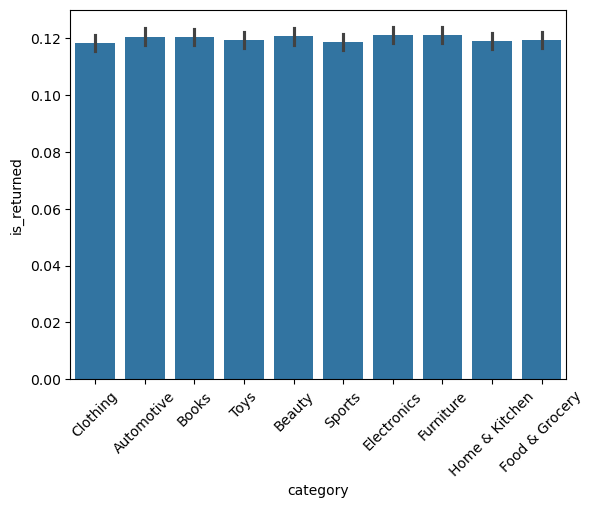

In [25]:
sns.barplot(
    data=df,
    x='category',
    y='is_returned'
)
plt.xticks(rotation=45)
plt.show()

Return Reasons

In [29]:
df[df['is_returned']==1]['return_reason'].value_counts()

return_reason
Not as Described      12080
Defective             12047
Wrong Item            11962
Better Price Found    11933
Changed Mind          11882
Name: count, dtype: int64

Phase 5: Build the full ColumnTransformer pipeline — different scalers for different columns, handle missings, encode categoricals.

Numerical Columns

In [ ]:
numeric_cols = [
    'product_base_price','discount_percentage','final_price','quantity','total_amount','shipping_cost','days_to_deliver','rating','num_reviews','customer_age','customer_lifetime_value','session_duration_mins','pages_viewed','clicks_to_purchase'
]

Ordinal Column

In [31]:
ordinal_cols = ['loyalty_tier']

Categorical Column

In [34]:
categorical_cols = [
    'category','sub_category','shipping_method','payment_method','customer_gender','country'
]

Remove unnecessary columns

In [33]:
drop_cols = ['order_id','customer_id','product_id','return_reason','city']

Create Pipelines

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler,OneHotEncoder,OrdinalEncoder,RobustScaler)

In [35]:
numerical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',RobustScaler())
])

In [36]:
categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [37]:
ordinal_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinal',OrdinalEncoder(
        categories=[
            ['Bronze','Silver','Gold','Platinum']
        ]
        
    ))
])

Phase 6 :
Are any features too correlated with each other? Which ones actually predict returns?

Correlation Matrix

In [38]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,order_id,customer_id,product_id,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,days_to_deliver,rating,num_reviews,customer_age,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled
order_id,1.000000,0.000963,-0.002462,0.000106,0.000253,0.000464,-0.000233,-0.000390,0.001662,0.000943,0.002348,0.002816,0.000851,0.000233,-0.000150,0.000863,0.001711,-0.003346,0.002068,-0.001975
customer_id,0.000963,1.000000,-0.000662,-0.000887,-0.000880,-0.000832,-0.000508,-0.001924,0.002150,-0.001703,-0.003234,-0.001371,0.001057,-0.001450,-0.001861,-0.000500,0.000253,-0.002652,-0.001203,0.000985
product_id,-0.002462,-0.000662,1.000000,-0.001356,-0.001079,-0.001279,0.001955,0.001648,-0.000733,-0.000379,0.000160,-0.001269,-0.000155,0.001550,0.002291,-0.001823,0.001793,-0.002768,-0.001383,-0.000842
product_base_price,0.000106,-0.000887,-0.001356,1.000000,0.000941,0.976290,0.001358,0.659634,-0.000261,0.000029,-0.001029,-0.001120,-0.001906,-0.000112,-0.000907,-0.001186,-0.000289,0.001058,-0.001294,0.000382
discount_percentage,0.000253,-0.000880,-0.001079,0.000941,1.000000,-0.156454,0.000897,-0.104974,-0.001303,-0.001524,-0.002359,0.000566,0.002561,0.001693,-0.001453,0.000752,0.001883,-0.001003,0.002670,-0.000228
final_price,0.000464,-0.000832,-0.001279,0.976290,-0.156454,1.000000,0.001233,0.675412,-0.000351,0.000094,-0.000447,-0.001103,-0.002095,-0.000619,-0.000814,-0.000793,-0.000272,0.001084,-0.001599,0.000235
quantity,-0.000233,-0.000508,0.001955,0.001358,0.000897,0.001233,1.000000,0.531041,0.000039,-0.001228,-0.002726,-0.000632,-0.000216,-0.001843,0.000820,-0.000040,-0.000018,0.000192,-0.000420,0.000590
total_amount,-0.000390,-0.001924,0.001648,0.659634,-0.104974,0.675412,0.531041,1.000000,-0.000271,-0.000715,-0.002282,-0.001184,-0.000207,-0.000950,-0.001208,-0.001255,-0.000217,0.000415,-0.001512,0.000699
shipping_cost,0.001662,0.002150,-0.000733,-0.000261,-0.001303,-0.000351,0.000039,-0.000271,1.000000,-0.001904,-0.000400,-0.000477,-0.000093,0.002229,-0.001088,-0.000177,-0.000186,-0.001563,-0.001265,-0.001660
days_to_deliver,0.000943,-0.001703,-0.000379,0.000029,-0.001524,0.000094,-0.001228,-0.000715,-0.001904,1.000000,-0.000714,-0.001165,0.001321,-0.001149,0.002084,-0.001014,-0.000657,0.000188,0.000614,-0.001146


Heatmap

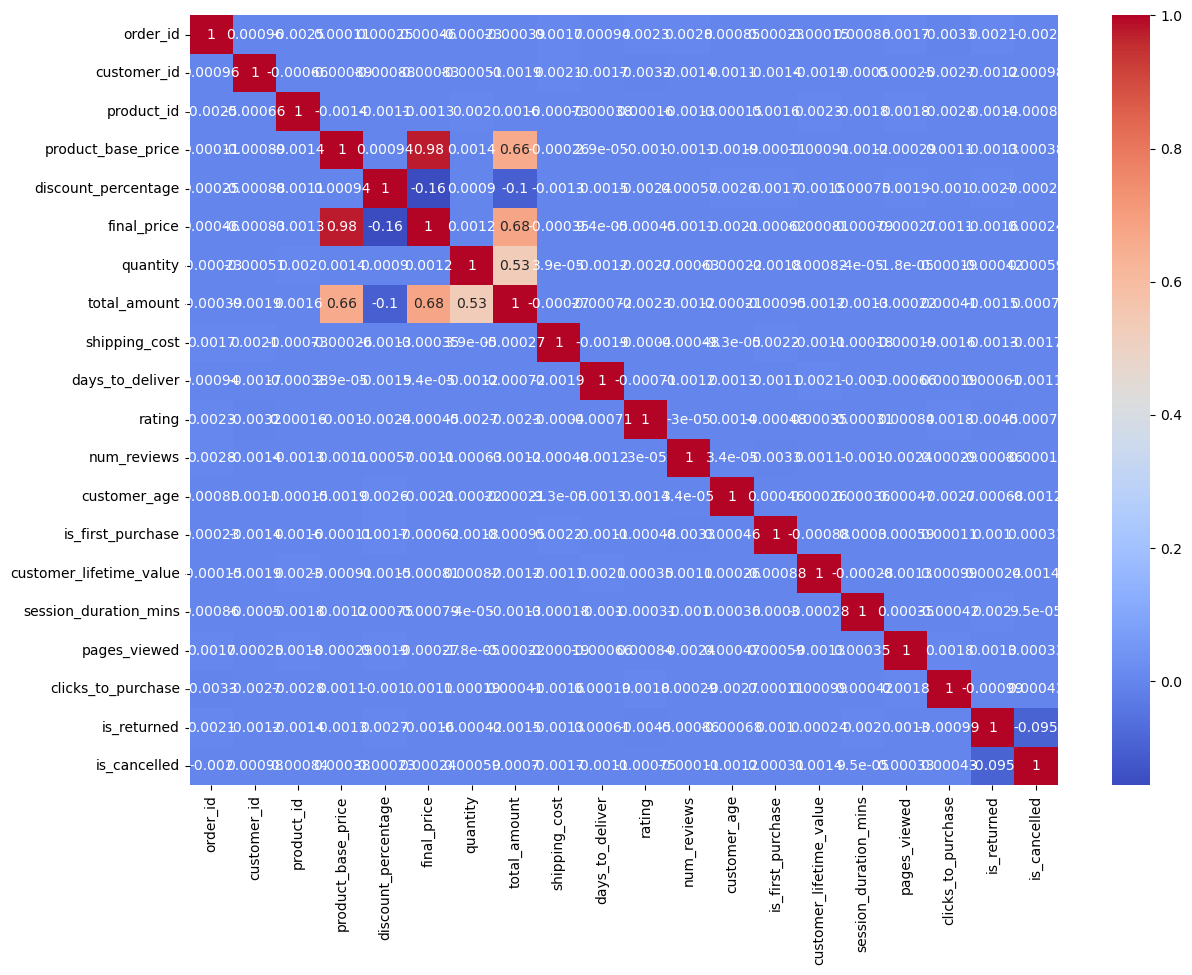

In [39]:

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.show()